##### Imports

In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys

##### Climb from the working directory to locate and load the associated source code.

In [2]:
from pathlib import Path
_p = Path(".").resolve()
while not (_p / "src" / "config.py").exists() and _p != _p.parent:
    _p = _p.parent
sys.path.insert(0, str(_p))
from src.config import ANALYSIS_DIR, FIGURES_DIR, PROJECT_ROOT, RESOURCES_DIR

##### Import custom code

In [3]:
from src.labels import gene_expr_bool, knn_label_transfer, neighbour_fraction
from src.markers import EEC_marker_panels
from src.palette import eec_palette
from src.plotting import gene_umaps, umap_panel


##### Where the panels are written, and the label orders used for legends and ratio bars.

In [4]:
FIGURE_DIR = FIGURES_DIR / "d10-lapa-eec"

COARSE_ORDER = ["Peptide EECs", "EC cells"]
HORMONE_ORDER = ["X cells", "D cells", "I cells", "K cells"]
GRANULAR_ORDER = HORMONE_ORDER + ["Enterochromaffin cells"]
ARX_ORDER = HORMONE_ORDER + ["Enterochromaffin cells", "ARX+ cells"]
FINAL_ORDER = HORMONE_ORDER + ["Enterochromaffin cells", "Early EECs"]

##### Subset the CellAssign predictions to EECs

##### The predictions object is written by 3-unsupervised_assignment.

In [5]:
d10_lapa = sc.read_h5ad(ANALYSIS_DIR / "data-objects/cellassign/d10_lapa_predictions.h5ad")
d10_lapa

AnnData object with n_obs × n_vars = 33507 × 28395
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'freemuxlet.identity', 'participant', 'Condition', 'Time_point', 'Treatment', 'ident', 'leiden', 'size_factor', 'initial_cellassign_prediction'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'X_name', 'hvg', 'initial_cellassign_prediction_colors', 'leiden_colors'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

##### Keep only the cells CellAssign called as EECs.

In [6]:
mask = d10_lapa.obs["initial_cellassign_prediction"].isin(["EECs"])
EECs_only = d10_lapa[mask].copy()
print(f"{EECs_only.n_obs:,} EECs of {d10_lapa.n_obs:,} cells")

819 EECs of 33,507 cells


##### Recluster the EECs on their own

In [7]:
if "counts" in EECs_only.layers:
    EECs_only.X = EECs_only.layers["counts"].copy()
    sc.pp.filter_genes(EECs_only, min_counts=1)
    sc.pp.normalize_total(EECs_only, target_sum=1e4)
    sc.pp.log1p(EECs_only)

sc.pp.highly_variable_genes(EECs_only, n_top_genes=3000, flavor="seurat_v3")
adata = EECs_only[:, EECs_only.var["highly_variable"]].copy()

# Keep the log-normalised values for plotting. sc.pp.scale below z-scores .X,
# which is what PCA wants but makes expression panels unreadable. Taking .raw
# from EECs_only also keeps all 28,395 genes, so marker panels are not limited
# to the 3,000 highly variable ones.
adata.raw = EECs_only

sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, n_comps=50, svd_solver="arpack")
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30)
sc.tl.umap(adata)

sc.tl.leiden(adata, resolution=0.3, key_added="leiden_subcluster")
adata.obs["leiden_subcluster"] = adata.obs["leiden_subcluster"].astype(str).astype("category")

/Users/standale/anaconda3/envs/single-cell-env/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:82: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  return fn(*args_all, **kw)
/Users/standale/anaconda3/envs/single-cell-env/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
/Users/standale/anaconda3/envs/single-cell-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/folders/rl/j_1783q13wv5fpfxhl3twdm80000gn/T/ipykernel_10640/738840869.py:21: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work wi

##### Restore the published UMAP layout, by loading the exact coordinates from the first ruy


In [8]:
canonical = np.load(RESOURCES_DIR / "embeddings/d10_eec_canonical_embedding.npz",
                    allow_pickle=True)
assert np.array_equal(adata.obs_names.to_numpy().astype(str), canonical["barcodes"]), (
    "cells no longer match the canonical embedding"
)
adata.obsm["X_umap"] = canonical["X_umap"]

##### Check the recluster against the whole-epithelium clustering.

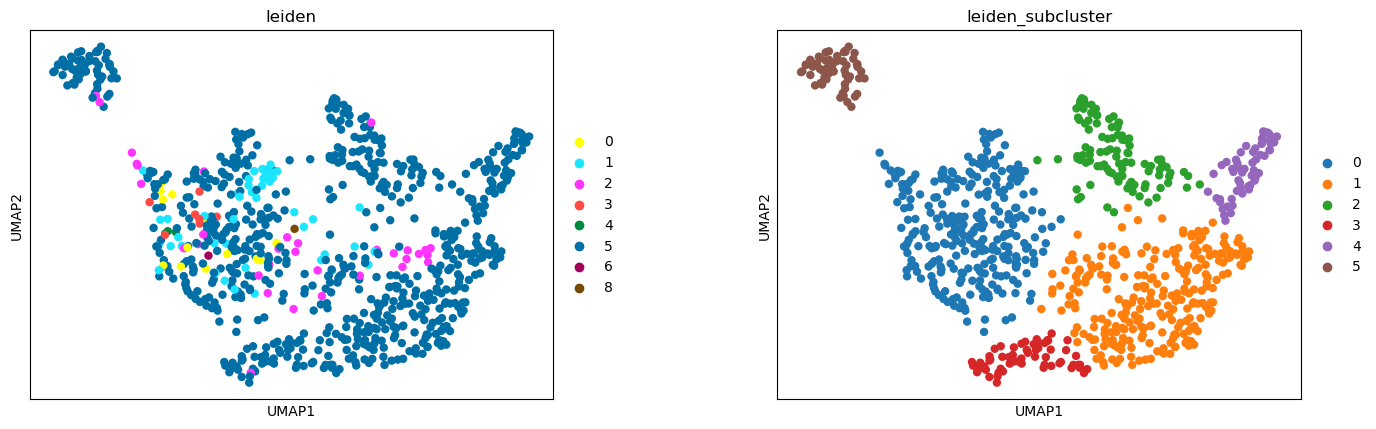

In [9]:
sc.pl.umap(adata, color=["leiden", "leiden_subcluster"], wspace=0.3)

##### Marker expression on the EEC UMAP

##### Enterochromaffin markers

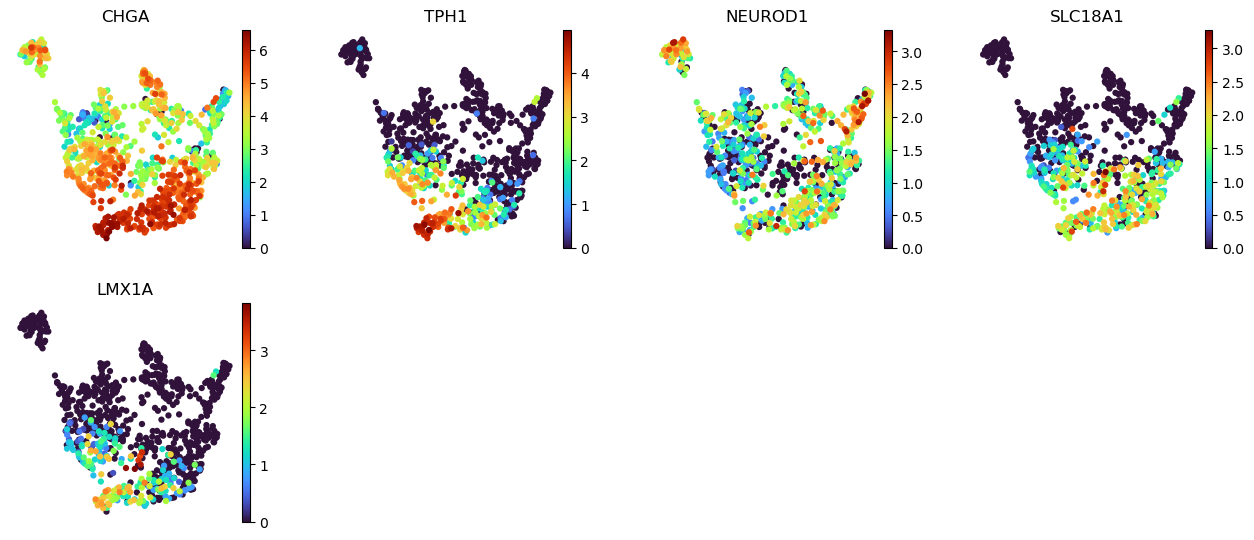

In [10]:
gene_umaps(adata, EEC_marker_panels["Enterochromaffin"], use_raw=True)

##### Peptide hormones

not in var_names: MLN


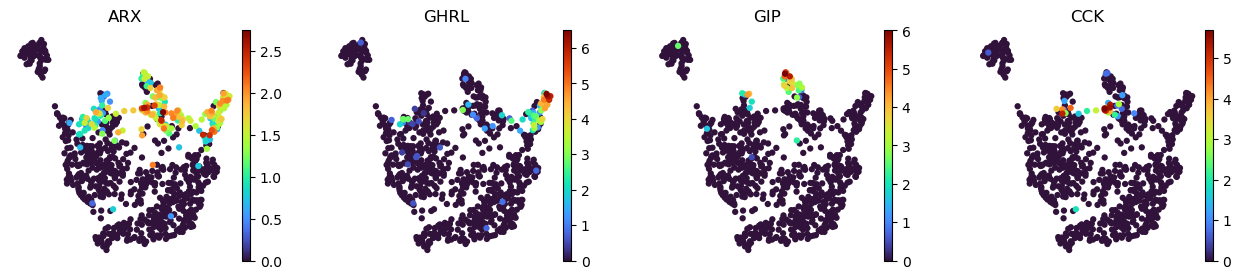

In [11]:
gene_umaps(adata, EEC_marker_panels["Peptide hormones"], use_raw=True)

##### More peptide hormones

not in var_names: GCG, NTS


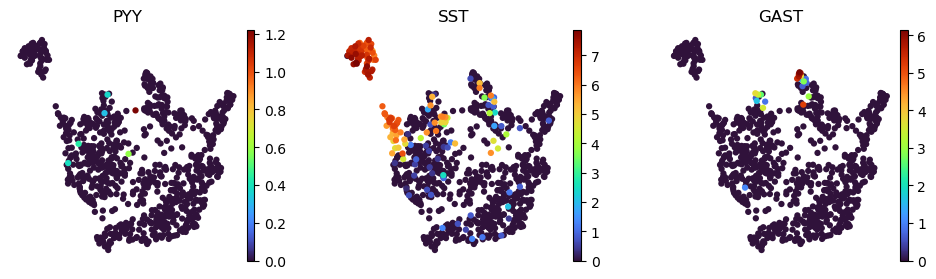

In [12]:
gene_umaps(adata, EEC_marker_panels["More peptide hormones"], use_raw=True)

##### Progenitor markers

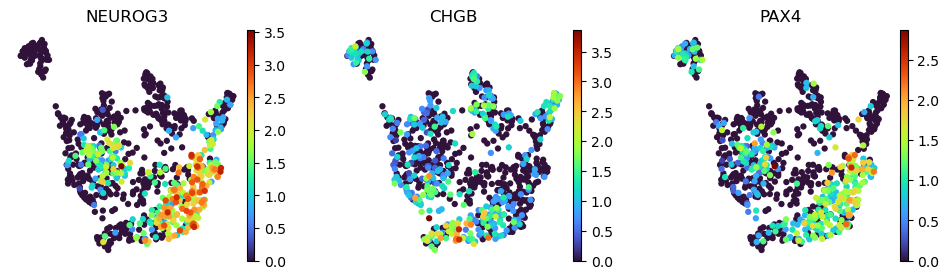

In [13]:
gene_umaps(adata, EEC_marker_panels["Progenitor"], use_raw=True)

##### TEAD Cofactors

not in var_names: PERCC1


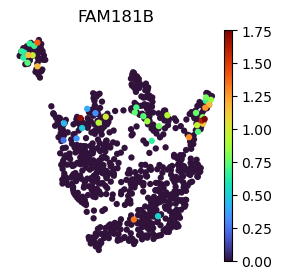

In [14]:
gene_umaps(adata, EEC_marker_panels["Cofactors"], use_raw=True)

##### Label v1 — splitting Enterochromaffin from peptide cells

In [15]:
peptide = gene_expr_bool(adata, "ARX") | gene_expr_bool(adata, "SST")

adata.obs["EEC_label"] = np.where(peptide, "Peptide EECs", "EC cells")
adata.obs["EEC_label"] = adata.obs["EEC_label"].astype("category")
print(adata.obs["EEC_label"].value_counts())

EEC_label
EC cells        523
Peptide EECs    296
Name: count, dtype: int64


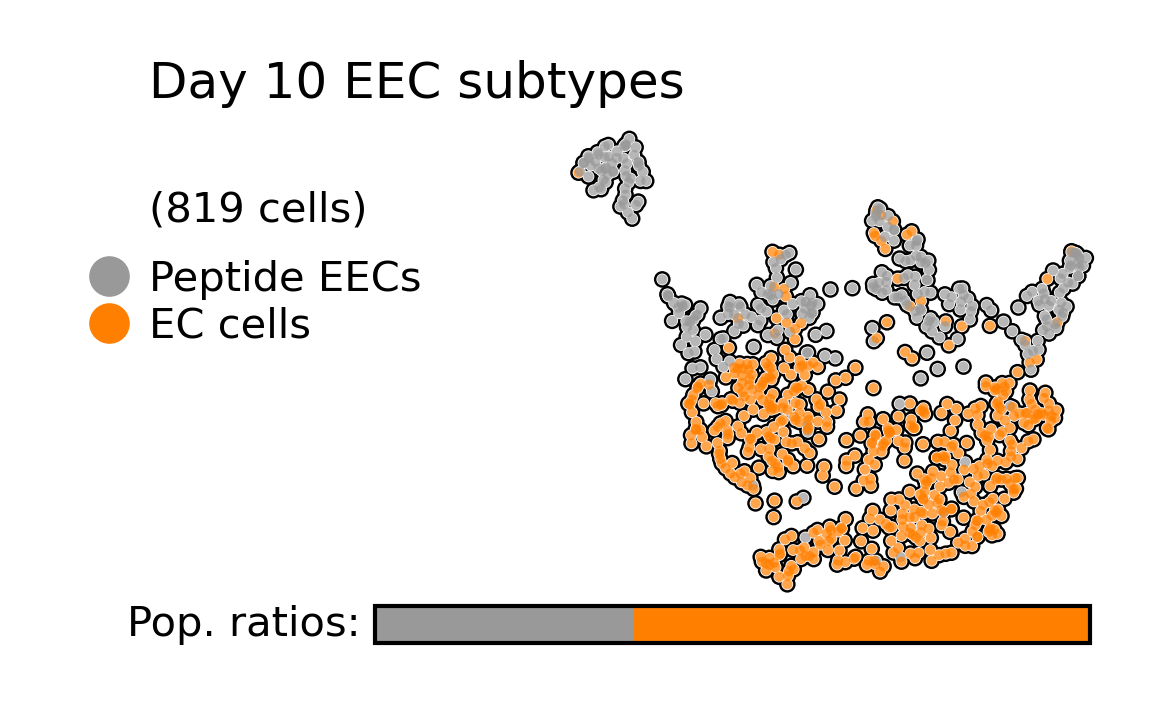

In [16]:
fig = umap_panel(
    adata, "EEC_label",
    palette=eec_palette,
    order=COARSE_ORDER,
    title="Day 10 EEC subtypes",
    save=FIGURE_DIR / "D10_simple_EEC_subtypes.pdf",
)
plt.show()

##### Label v1 granular — hormone gates at any detected expression

In [17]:
## Each hormone gate is applied in turn, so a later gate overrides an earlier one where a cell is positive for both. This would be problematic if the heat maps didn't illustrate the expression is essentially mutually exclusive.

adata.obs["granular_EEC_label"] = "Enterochromaffin cells"
for gene, label in [("GHRL", "X cells"), ("SST", "D cells"),
                    ("CCK", "I cells"), ("GIP", "K cells")]:
    adata.obs.loc[gene_expr_bool(adata, gene), "granular_EEC_label"] = label

adata.obs["granular_EEC_label"] = adata.obs["granular_EEC_label"].astype("category")
print(adata.obs["granular_EEC_label"].value_counts())

granular_EEC_label
Enterochromaffin cells    572
D cells                   122
X cells                    62
K cells                    36
I cells                    27
Name: count, dtype: int64


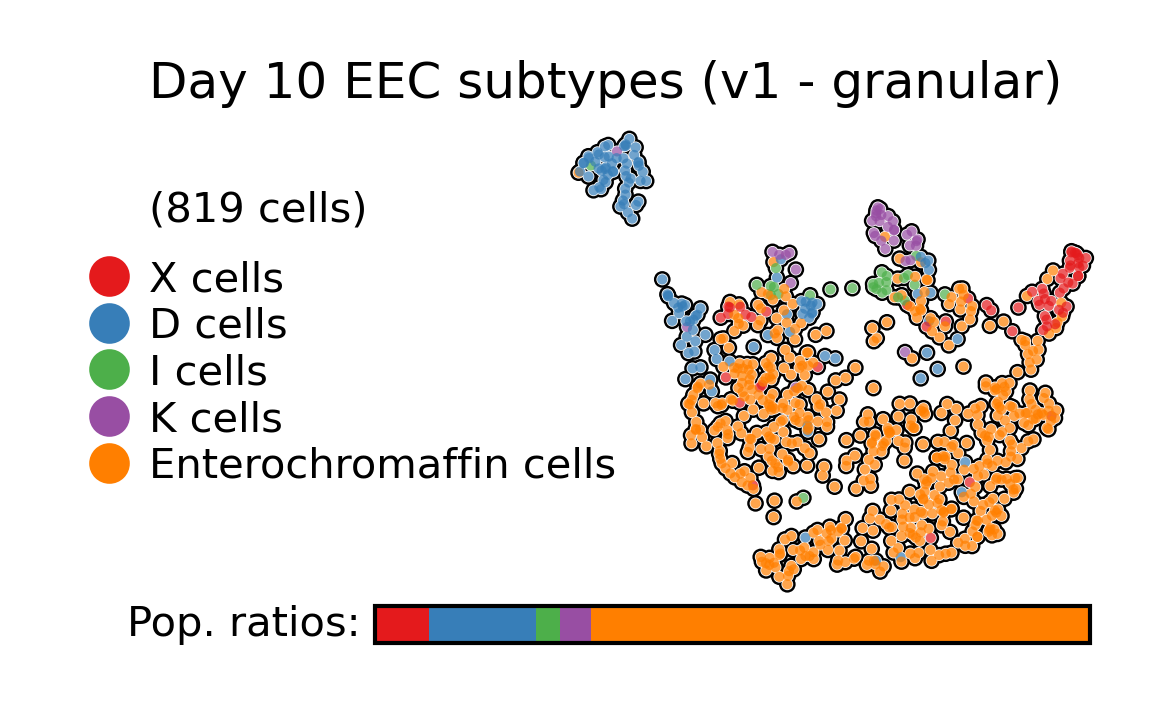

In [18]:
fig = umap_panel(
    adata, "granular_EEC_label",
    palette=eec_palette,
    order=GRANULAR_ORDER,
    title="Day 10 EEC subtypes (v1 - granular)",
    save=FIGURE_DIR / "D10_EEC_subtypes.pdf",
)
plt.show()

##### Label v2 — reassign ARX+ cells without a clear hormone via kNN

In [19]:
## Cells that are ARX-positive but carry no specific hormone are held out as their own class rather than defaulting to EC cells. Then, the pre-existing kNN graph is used to assign cells in a weighted fashion to one of the peptide classes.

adata.obs["granular_EEC_label_v2"] = "Enterochromaffin cells"
adata.obs.loc[gene_expr_bool(adata, "ARX"), "granular_EEC_label_v2"] = "ARX+ cells"
for gene, label in [("GHRL", "X cells"), ("SST", "D cells"),
                    ("CCK", "I cells"), ("GIP", "K cells")]:
    adata.obs.loc[gene_expr_bool(adata, gene), "granular_EEC_label_v2"] = label

adata.obs["granular_EEC_label_v2"] = adata.obs["granular_EEC_label_v2"].astype("category")
print(adata.obs["granular_EEC_label_v2"].value_counts())

granular_EEC_label_v2
Enterochromaffin cells    499
D cells                   122
ARX+ cells                 73
X cells                    62
K cells                    36
I cells                    27
Name: count, dtype: int64


##### Before the transfer, with the held-out cells shown in pink.

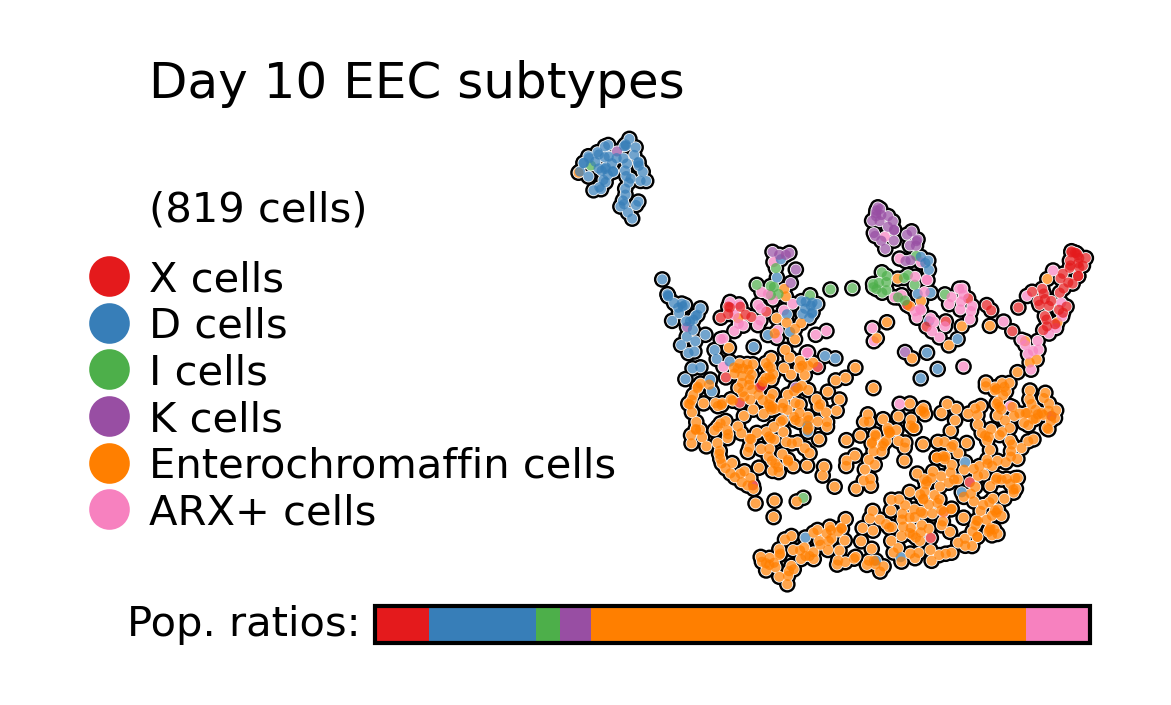

In [20]:
fig = umap_panel(
    adata, "granular_EEC_label_v2",
    palette=eec_palette,
    order=ARX_ORDER,
    title="Day 10 EEC subtypes",
    save=FIGURE_DIR / "D10_EEC_subtypes_ARX.pdf",
)
plt.show()

In [21]:
transferred = knn_label_transfer(
    adata, "granular_EEC_label_v2",
    query_label="ARX+ cells",
    reference_labels=HORMONE_ORDER,
    n_passes=2,
)
print(f"transferred {len(transferred)} cells, mean confidence {transferred.confidence.mean():.3f}")
print()
print(transferred.prediction.value_counts())

transferred 73 cells, mean confidence 0.722

prediction
X cells    37
D cells    21
I cells    11
K cells     4
Name: count, dtype: int64


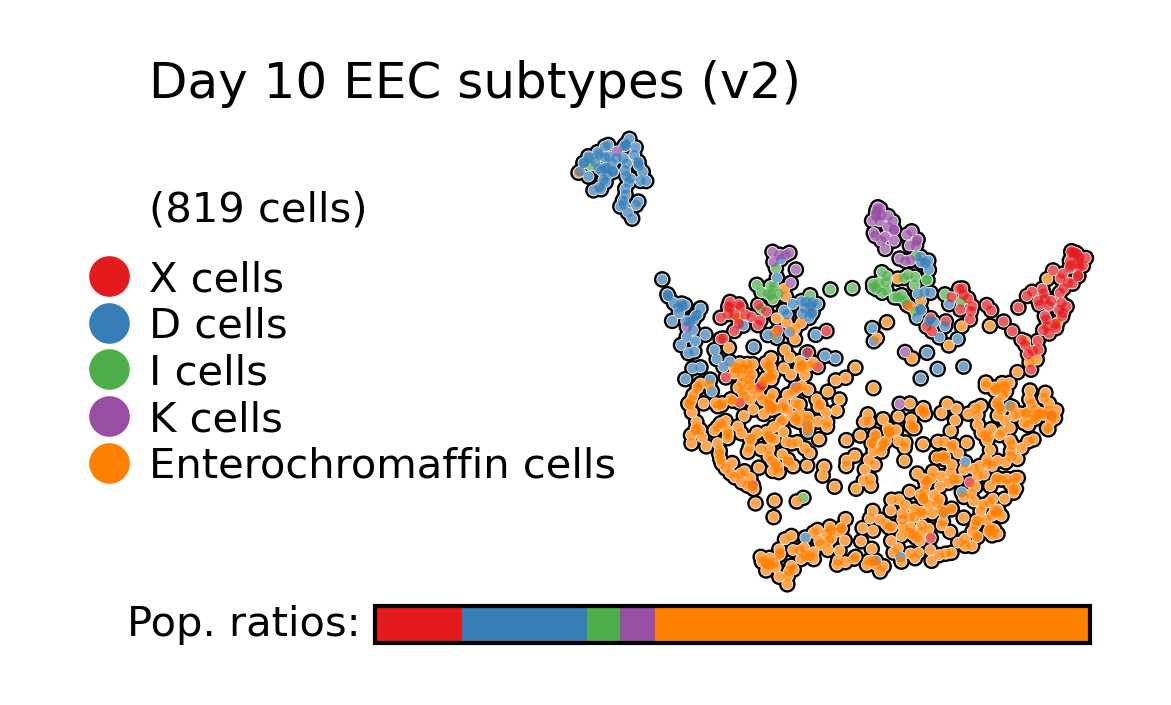

In [22]:
fig = umap_panel(
    adata, "granular_EEC_label_v2",
    palette=eec_palette,
    order=GRANULAR_ORDER,
    title="Day 10 EEC subtypes (v2)",
    save=FIGURE_DIR / "D10_EEC_subtypes_kNN_refined.pdf",
)
plt.show()

##### Labels v3 and v4 — a NEUROG3 threshold for Early EECs

In [23]:
## The enterochromaffin pool still holds NEUROG3-high cells that look immature rather than committed to the EC lineage. Look at early markers and use them to assign an Early EEC label based on z-scored gene expression.


In [24]:
for version, cutoff in [("granular_EEC_label_v3", 1.5), ("granular_EEC_label_v4", 1.0)]:
    adata.obs[version] = adata.obs["granular_EEC_label_v2"].astype(str)
    reassign = (adata.obs[version] == "Enterochromaffin cells") & gene_expr_bool(adata, "NEUROG3", cutoff)
    adata.obs.loc[reassign, version] = "Early EECs"
    adata.obs[version] = adata.obs[version].astype("category")
    print(f"NEUROG3 > {cutoff}: {reassign.sum()} cells reassigned to Early EECs")

NEUROG3 > 1.5: 95 cells reassigned to Early EECs
NEUROG3 > 1.0: 161 cells reassigned to Early EECs


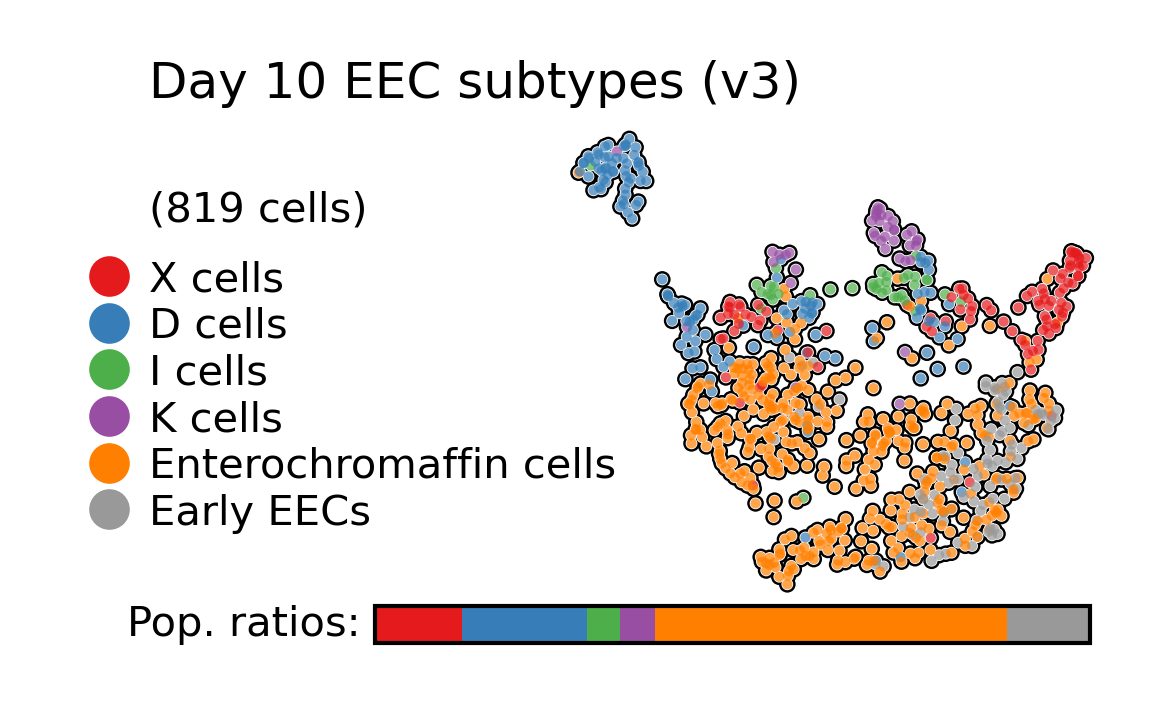

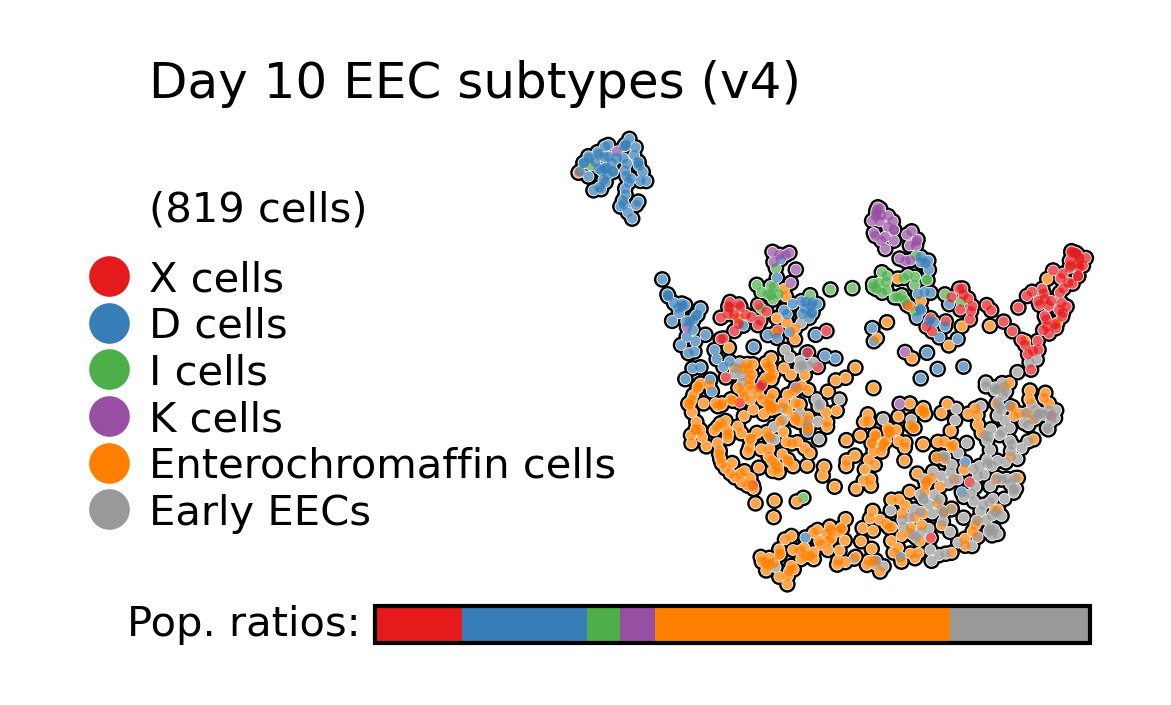

In [25]:
TITLES = {
    "granular_EEC_label_v3": "Day 10 EEC subtypes (v3)",
    "granular_EEC_label_v4": "Day 10 EEC subtypes (v4)",
}

for version, cutoff in [("granular_EEC_label_v3", 1.5), ("granular_EEC_label_v4", 1.0)]:
    fig = umap_panel(
        adata, version,
        palette=eec_palette,
        order=FINAL_ORDER,
        title=TITLES[version],
        save=FIGURE_DIR / f"D10_EEC_subtypes_{version[-2:]}.pdf",
    )
    plt.show()

##### Label v5 — hormone assignment using a threshold for higher fidelity & expanding use of kNN for assignment post hoc

In [26]:
## Strict gates. Early EECs are set before the transfer so they are held out.

In [27]:
adata.obs["granular_EEC_label_v5"] = "Enterochromaffin cells"

for gene, label, cutoff in [("GHRL", "X cells", 4.0), ("SST", "D cells", 2.5),
                            ("CCK", "I cells", 3.0), ("GIP", "K cells", 4.0)]:
    adata.obs.loc[gene_expr_bool(adata, gene, cutoff), "granular_EEC_label_v5"] = label

unassigned = adata.obs["granular_EEC_label_v5"] == "Enterochromaffin cells"
adata.obs.loc[unassigned & gene_expr_bool(adata, "NEUROG3", 1.0), "granular_EEC_label_v5"] = "Early EECs"

unassigned = adata.obs["granular_EEC_label_v5"] == "Enterochromaffin cells"
adata.obs.loc[unassigned & gene_expr_bool(adata, "ARX"), "granular_EEC_label_v5"] = "ARX+ cells"

adata.obs["granular_EEC_label_v5"] = adata.obs["granular_EEC_label_v5"].astype("category")
print(adata.obs["granular_EEC_label_v5"].value_counts())

granular_EEC_label_v5
Enterochromaffin cells    413
Early EECs                170
ARX+ cells                130
D cells                    54
K cells                    19
I cells                    17
X cells                    16
Name: count, dtype: int64


In [28]:
## Resolve ARX+ cells to a peptide cell type.

In [29]:
transferred = knn_label_transfer(
    adata, "granular_EEC_label_v5",
    query_label="ARX+ cells",
    reference_labels=HORMONE_ORDER,
    n_passes=2,
    unresolved="Enterochromaffin cells",
)
print(f"transferred {len(transferred)} cells, mean confidence {transferred.confidence.mean():.3f}")
print()
print(adata.obs["granular_EEC_label_v5"].value_counts())

transferred 129 cells, mean confidence 0.905

granular_EEC_label_v5
Enterochromaffin cells    414
Early EECs                170
I cells                    72
D cells                    71
X cells                    51
K cells                    41
Name: count, dtype: int64


In [30]:
##### Step 3 — enterochromaffin calls sitting in a mostly peptide-hormone neighbourhood are rescued through the same transfer. 

In [31]:
labels = adata.obs["granular_EEC_label_v5"].astype(str).to_numpy()
peptide_frac = neighbour_fraction(adata, np.isin(labels, HORMONE_ORDER))

rescue = (labels == "Enterochromaffin cells") & (peptide_frac > 0.35)
print(f"{rescue.sum()} enterochromaffin cells above the connectivity cutoff")

adata.obs["granular_EEC_label_v5"] = adata.obs["granular_EEC_label_v5"].astype(str)
adata.obs.loc[rescue, "granular_EEC_label_v5"] = "EC candidate"

rescued = knn_label_transfer(
    adata, "granular_EEC_label_v5",
    query_label="EC candidate",
    reference_labels=HORMONE_ORDER,
    unresolved="Enterochromaffin cells",
)
print(f"rescued {len(rescued)} cells, mean confidence {rescued.confidence.mean():.3f}")
print()
print(rescued.prediction.value_counts())

51 enterochromaffin cells above the connectivity cutoff
rescued 51 cells, mean confidence 0.873

prediction
D cells    29
I cells    12
K cells     5
X cells     5
Name: count, dtype: int64


##### Final labels, saved twice: the native 44.5 x 25.4 mm print panel, and my custom dimensions for slides

In [32]:
adata.obs["granular_EEC_label_v5"] = (
    adata.obs["granular_EEC_label_v5"].cat.remove_unused_categories()
)
print(adata.obs["granular_EEC_label_v5"].value_counts())

granular_EEC_label_v5
Enterochromaffin cells    363
Early EECs                170
D cells                   100
I cells                    84
X cells                    56
K cells                    46
Name: count, dtype: int64


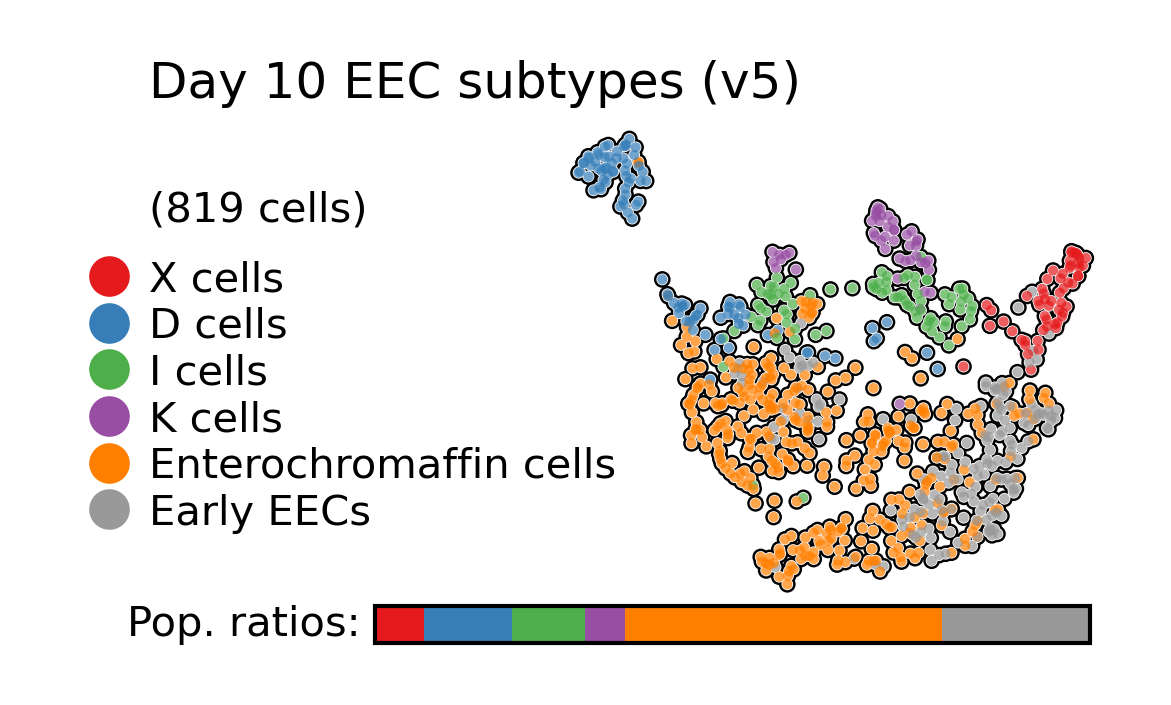

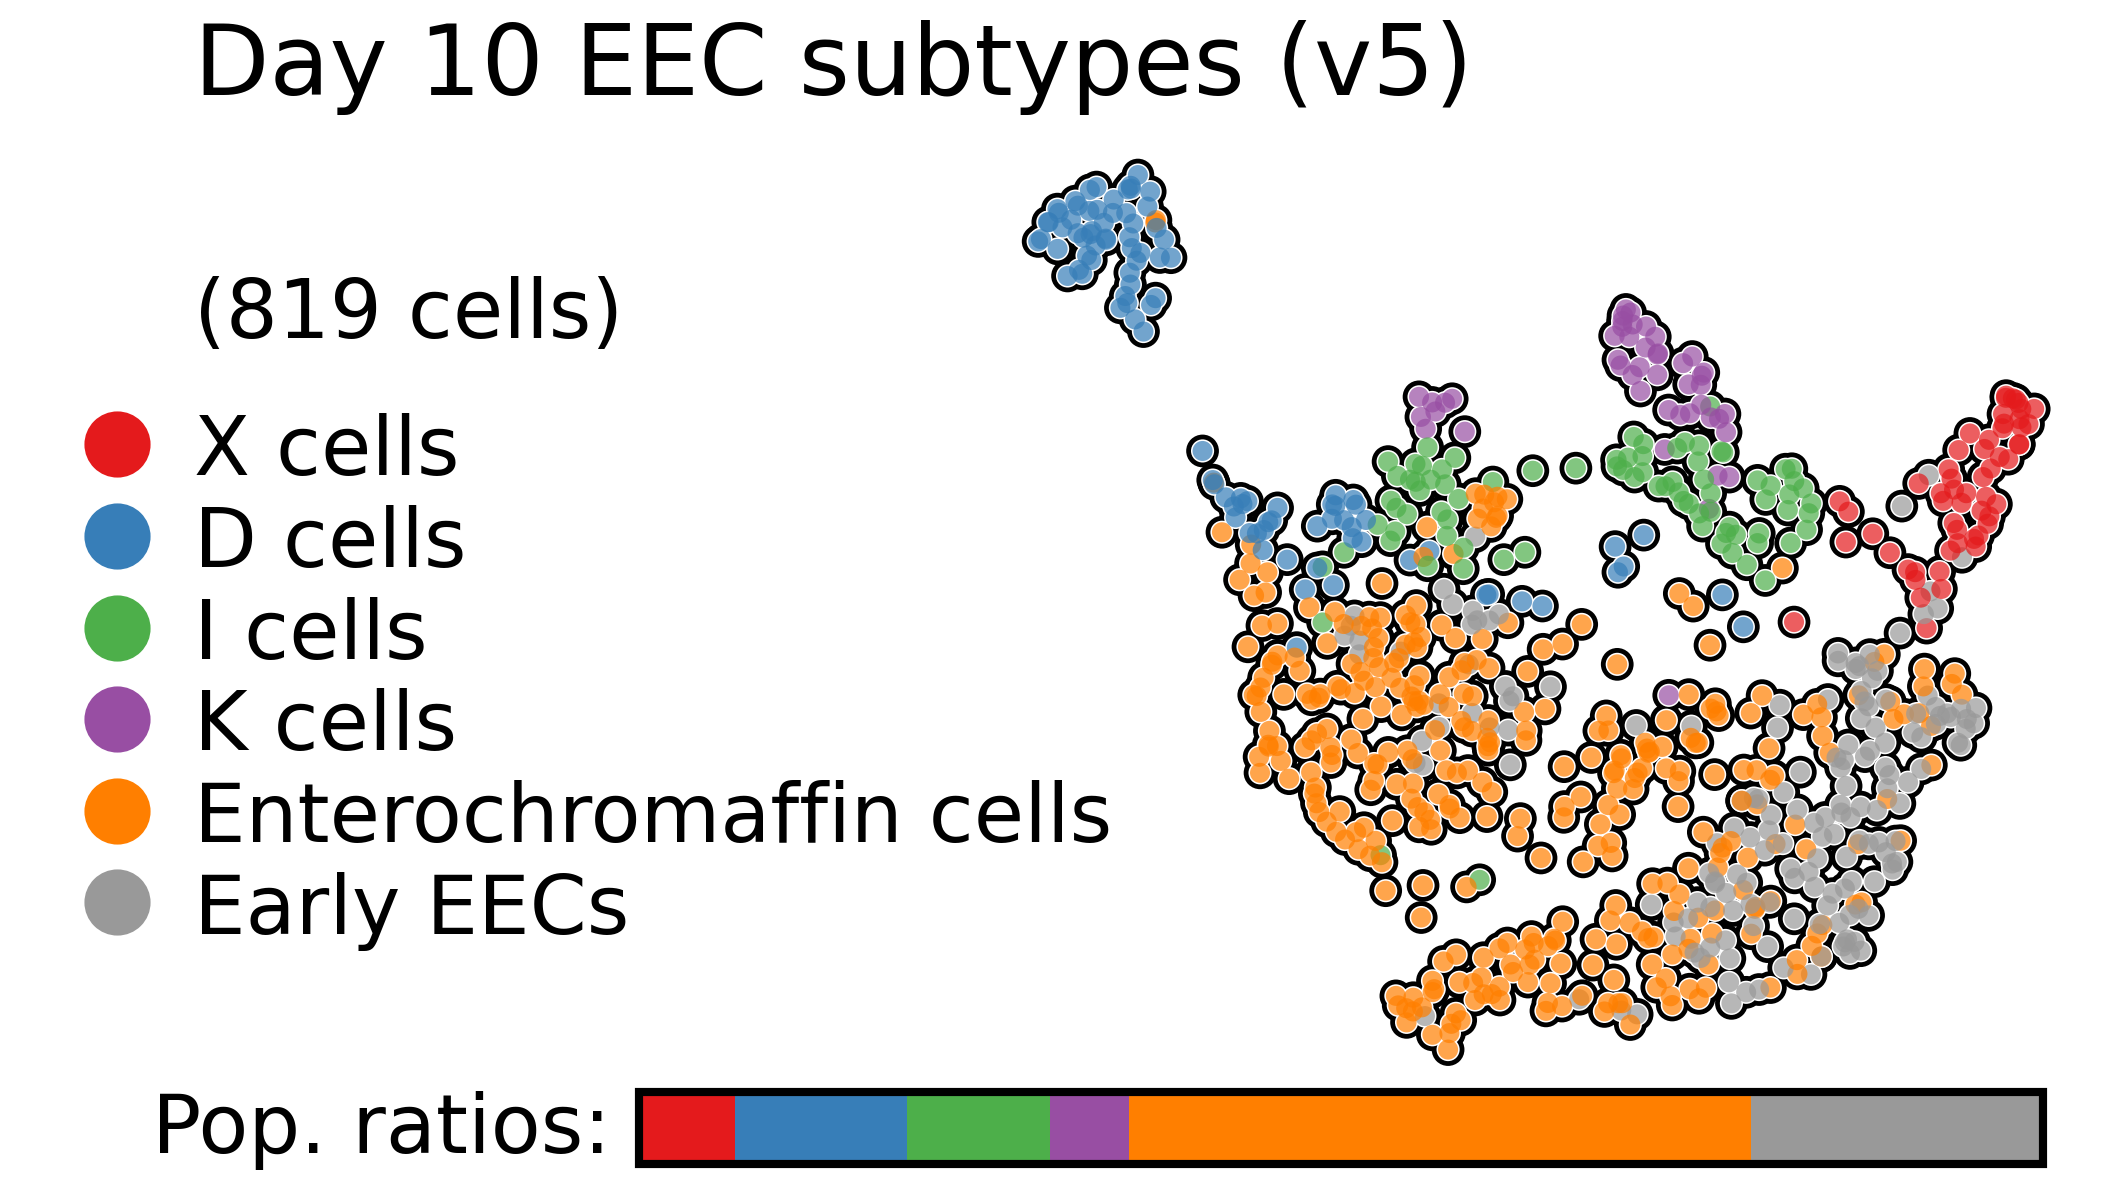

In [33]:
for slot, suffix, dpi in [("print", "", 600), ("single", "_slide", 200)]:
    fig = umap_panel(
        adata, "granular_EEC_label_v5",
        palette=eec_palette,
        order=FINAL_ORDER,
        title="Day 10 EEC subtypes (v5)",
        slot=slot,
        dpi=dpi,
        save=FIGURE_DIR / f"D10_EEC_subtypes_v5{suffix}.pdf",
    )
    plt.show()

##### An untitled copy for the README, where the surrounding text names the figure.

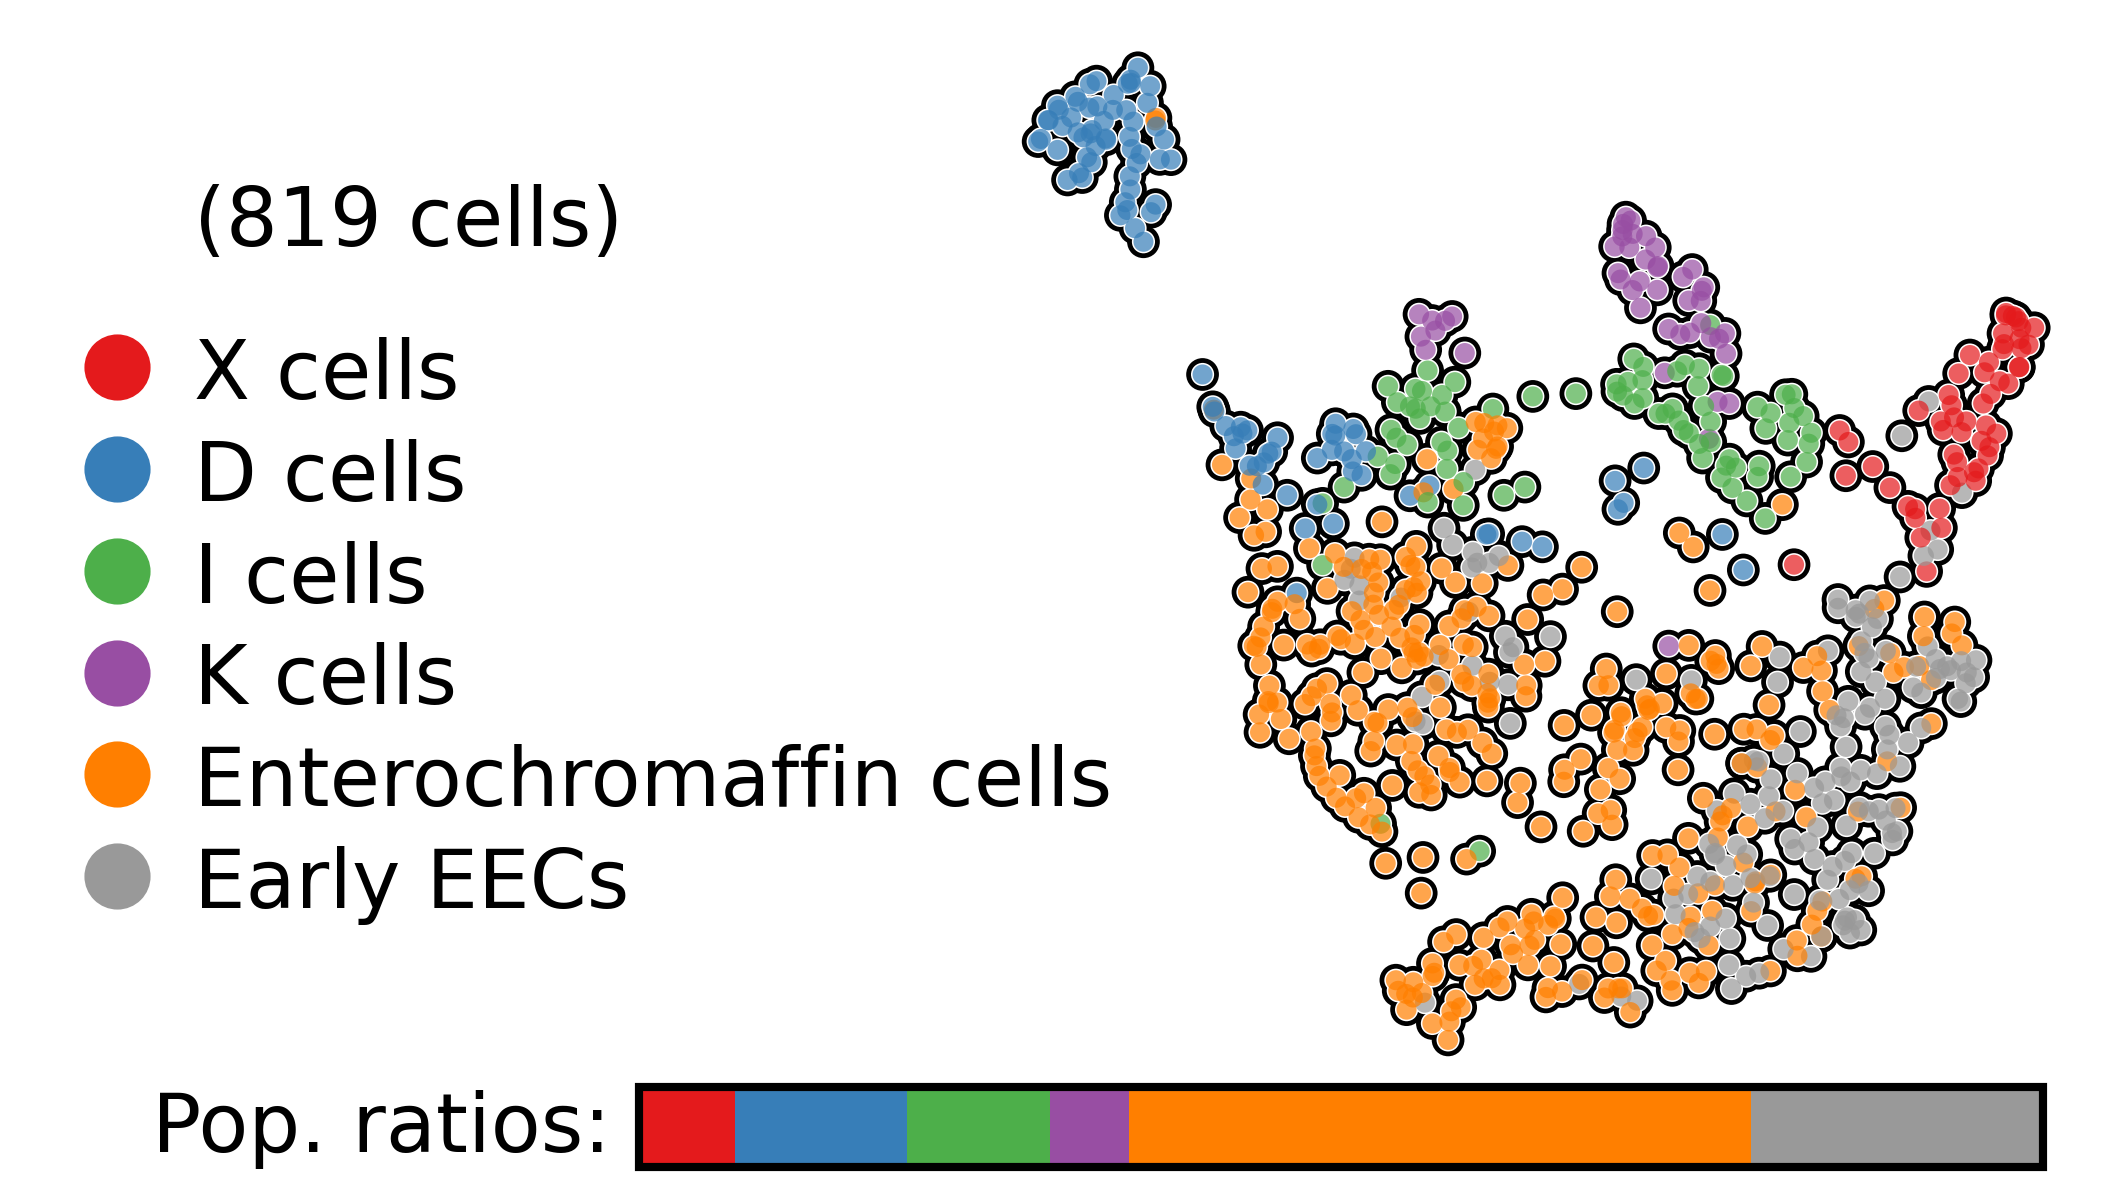

In [34]:
## Saved opaque for GitHub and transparent for slides.

fig = umap_panel(
    adata, "granular_EEC_label_v5",
    palette=eec_palette,
    order=FINAL_ORDER,
    slot="single",
    dpi=200,
    save=FIGURE_DIR / "D10_EEC_subtypes_v5_untitled.pdf",
)
fig.savefig(PROJECT_ROOT / "docs/eec_subtypes_v5.png", dpi=200,
            transparent=False, facecolor="white")
fig.savefig(PROJECT_ROOT / "docs/eec_subtypes_v5_transparent.png", dpi=200,
            transparent=True)
plt.show()

##### Save the labelled object

In [35]:
out = ANALYSIS_DIR / "data-objects/labelled/knn_EECs_egfDuod_D10_Lapa_DZ.h5ad"
out.parent.mkdir(parents=True, exist_ok=True)
adata.write_h5ad(out)
print(f"wrote {out}")

wrote /Users/standale/user_generated/Work/breault-lab/single-cell/EGFRi-organoid-single-cell/data/data-objects/labelled/knn_EECs_egfDuod_D10_Lapa_DZ.h5ad
